# 05 - Análisis de fairness

Este notebook evalúa si el modelo final mantiene un rendimiento equilibrado entre subgrupos sensibles y resume una mitigación basada en umbrales por grupo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

pd.set_option("display.max_columns", None)

os.makedirs("../results/tables", exist_ok=True)
os.makedirs("../results/figures", exist_ok=True)
os.makedirs("../results/fairness", exist_ok=True)

## Carga de modelo, test y predicciones

Se recuperan el mejor modelo, la partición de test y las predicciones guardadas. `predictions_df` es la tabla base para calcular las métricas de equidad.

In [2]:
best_model = joblib.load("../results/models/best_model.pkl")
best_model_name = joblib.load("../results/models/best_model_name.pkl")

X_test = joblib.load("../results/models/X_test.pkl")
y_test = joblib.load("../results/models/y_test.pkl")

predictions_df = pd.read_csv("../results/tables/best_model_predictions.csv")

print("Modelo:", best_model_name)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("predictions_df:", predictions_df.shape)

predictions_df.head()

Modelo: Gradient Boosting
X_test: (885, 28)
y_test: (885,)
predictions_df: (885, 31)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Unemployment rate,Inflation rate,GDP,y_real,y_pred,y_proba_dropout
0,1,1,2,14,1,1,1,1,14,5,8,1,0,0,1,0,1,18,0,0,6,6,6,13.166667,0,8.9,1.4,3.51,0,0,0.039526
1,1,1,1,7,1,1,1,13,27,6,9,1,0,0,1,1,0,18,0,0,5,9,4,10.500000,0,7.6,2.6,0.32,0,0,0.180899
2,1,4,1,4,1,3,1,24,29,10,5,0,0,0,1,1,0,50,0,2,6,8,2,13.500000,0,15.5,2.8,-4.06,1,1,0.902840
3,1,1,2,12,1,1,1,1,3,5,4,0,0,0,1,0,0,18,0,0,7,10,7,13.398000,0,15.5,2.8,-4.06,0,0,0.046768
4,1,9,1,15,1,1,1,23,28,7,8,1,0,0,1,1,1,18,0,0,6,6,1,11.000000,0,8.9,1.4,3.51,1,1,0.623594


## Variables sensibles disponibles

Se seleccionan variables de subgrupo relevantes: género, beca, deuda, tasas al día e internacionalidad. Solo se usan las columnas presentes en la tabla de predicciones.

In [3]:
fairness_cols = [
    "Gender",
    "Scholarship holder",
    "Debtor",
    "Tuition fees up to date",
    "International"
]

available_fairness_cols = [col for col in fairness_cols if col in predictions_df.columns]

available_fairness_cols

['Gender',
 'Scholarship holder',
 'Debtor',
 'Tuition fees up to date',
 'International']

## Distribución por subgrupos

Antes de comparar métricas, se revisa cuántos estudiantes hay en cada grupo. Los grupos pequeños deben interpretarse con más cautela.

In [4]:
for col in available_fairness_cols:
    print(f"\n{col}")
    print(predictions_df[col].value_counts(dropna=False))


Gender
Gender
0    564
1    321
Name: count, dtype: int64

Scholarship holder
Scholarship holder
0    654
1    231
Name: count, dtype: int64

Debtor
Debtor
0    795
1     90
Name: count, dtype: int64

Tuition fees up to date
Tuition fees up to date
1    771
0    114
Name: count, dtype: int64

International
International
0    859
1     26
Name: count, dtype: int64


## Métricas por grupo

La función calcula rendimiento para cada subgrupo: accuracy, precision, recall, F1, falsos positivos y falsos negativos. En abandono, el recall y la tasa de falsos negativos son especialmente críticos.

In [5]:
def compute_group_metrics(df, group_col):
    rows = []

    for group_value, group_df in df.groupby(group_col):
        y_true = group_df["y_real"]
        y_pred = group_df["y_pred"]

        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        rows.append({
            "variable": group_col,
            "group": group_value,
            "n_students": len(group_df),
            "real_dropout_rate": y_true.mean(),
            "predicted_dropout_rate": y_pred.mean(),
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "false_positive_rate": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
            "false_negative_rate": fn / (fn + tp) if (fn + tp) > 0 else np.nan,
            "true_positives": tp,
            "false_positives": fp,
            "true_negatives": tn,
            "false_negatives": fn
        })

    return pd.DataFrame(rows)

## Resultados de fairness

Se aplican las métricas a todas las variables sensibles disponibles y se obtiene una tabla comparable entre grupos.

In [6]:
fairness_results = pd.concat(
    [compute_group_metrics(predictions_df, col) for col in available_fairness_cols],
    ignore_index=True
)

fairness_results

,variable,group,n_students,real_dropout_rate,predicted_dropout_rate,accuracy,precision,recall,f1,false_positive_rate,false_negative_rate,true_positives,false_positives,true_negatives,false_negatives
0,Gender,0,564,0.244681,0.209220,0.886525,0.813559,0.695652,0.750000,0.051643,0.304348,96,22,404,42
1,Gender,1,321,0.454829,0.386293,0.813084,0.846774,0.719178,0.777778,0.108571,0.280822,105,19,156,41
2,Scholarship holder,0,654,0.389908,0.339450,0.839450,0.837838,0.729412,0.779874,0.090226,0.270588,186,36,363,69
3,Scholarship holder,1,231,0.125541,0.086580,0.917749,0.750000,0.517241,0.612245,0.024752,0.482759,15,5,197,14
4,Debtor,0,795,0.291824,0.227673,0.862893,0.839779,0.655172,0.736077,0.051510,0.344828,152,29,534,80
5,Debtor,1,90,0.577778,0.677778,0.833333,0.803279,0.942308,0.867257,0.315789,0.057692,49,12,26,3
6,Tuition fees up to date,0,114,0.859649,0.938596,0.903509,0.906542,0.989796,0.946341,0.625000,0.010204,97,10,6,1
7,Tuition fees up to date,1,771,0.241245,0.175097,0.853437,0.770370,0.559140,0.647975,0.052991,0.440860,104,31,554,82
8,International,0,859,0.321304,0.267753,0.860303,0.839130,0.699275,0.762846,0.063465,0.300725,193,37,546,83
9,International,1,26,0.307692,0.461538,0.846154,0.666667,1.000000,0.800000,0.222222,0.000000,8,4,14,0


In [7]:
fairness_results.to_csv(
    "../results/tables/fairness_group_metrics.csv",
    index=False
)

## Brechas entre grupos

Las brechas miden la diferencia entre el mejor y el peor grupo para cada métrica. Sirven para priorizar qué variables requieren más atención.

In [8]:
fairness_gap_rows = []

for col in available_fairness_cols:
    subset = fairness_results[fairness_results["variable"] == col]

    fairness_gap_rows.append({
        "variable": col,
        "n_groups": subset["group"].nunique(),
        "max_recall_gap": subset["recall"].max() - subset["recall"].min(),
        "max_f1_gap": subset["f1"].max() - subset["f1"].min(),
        "max_false_positive_rate_gap": subset["false_positive_rate"].max() - subset["false_positive_rate"].min(),
        "max_false_negative_rate_gap": subset["false_negative_rate"].max() - subset["false_negative_rate"].min(),
        "max_predicted_dropout_rate_gap": subset["predicted_dropout_rate"].max() - subset["predicted_dropout_rate"].min(),
        "max_real_dropout_rate_gap": subset["real_dropout_rate"].max() - subset["real_dropout_rate"].min()
    })

fairness_gaps = pd.DataFrame(fairness_gap_rows).sort_values(
    by="max_f1_gap",
    ascending=False
)

fairness_gaps.to_csv(
    "../results/tables/fairness_metric_gaps.csv",
    index=False
)

fairness_gaps

,variable,n_groups,max_recall_gap,max_f1_gap,max_false_positive_rate_gap,max_false_negative_rate_gap,max_predicted_dropout_rate_gap,max_real_dropout_rate_gap
3,Tuition fees up to date,2,0.430656,0.298366,0.572009,0.430656,0.763499,0.618404
1,Scholarship holder,2,0.212170,0.167629,0.065473,0.212170,0.252869,0.264367
2,Debtor,2,0.287135,0.131179,0.264280,0.287135,0.450105,0.285954
4,International,2,0.300725,0.037154,0.158757,0.300725,0.193785,0.013612
0,Gender,2,0.023526,0.027778,0.056928,0.023526,0.177073,0.210148


## Gráficos de comparación

Las visualizaciones de recall, F1 y tasa de falsos negativos facilitan detectar rápidamente grupos donde el modelo falla más.

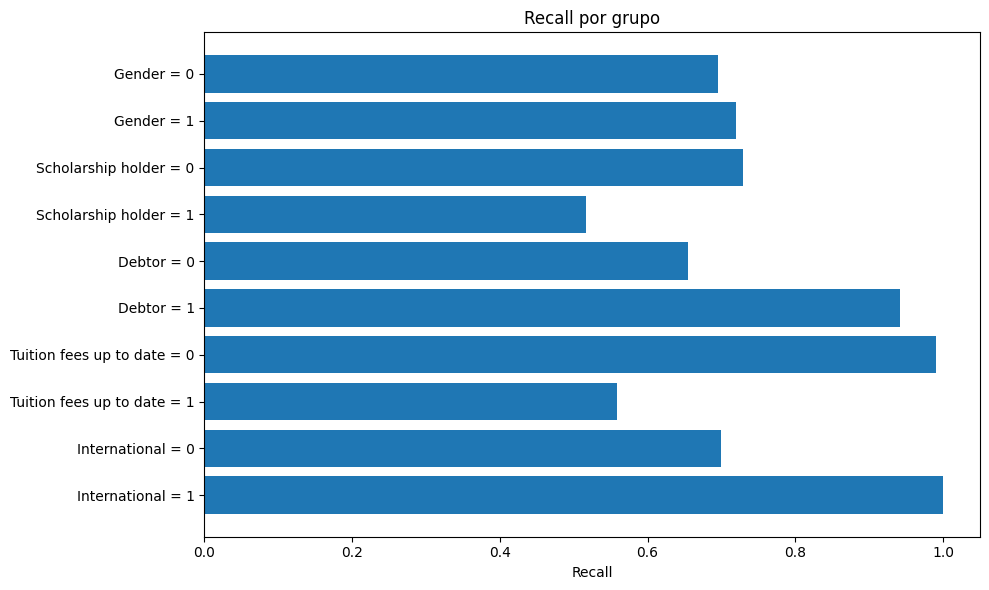

In [9]:
plt.figure(figsize=(10, 6))

plot_df = fairness_results.copy()
plot_df["label"] = plot_df["variable"].astype(str) + " = " + plot_df["group"].astype(str)

plt.barh(
    plot_df["label"][::-1],
    plot_df["recall"][::-1]
)

plt.xlabel("Recall")
plt.title("Recall por grupo")
plt.tight_layout()
plt.savefig("../results/figures/fairness_recall_by_group.png", dpi=300)
plt.show()

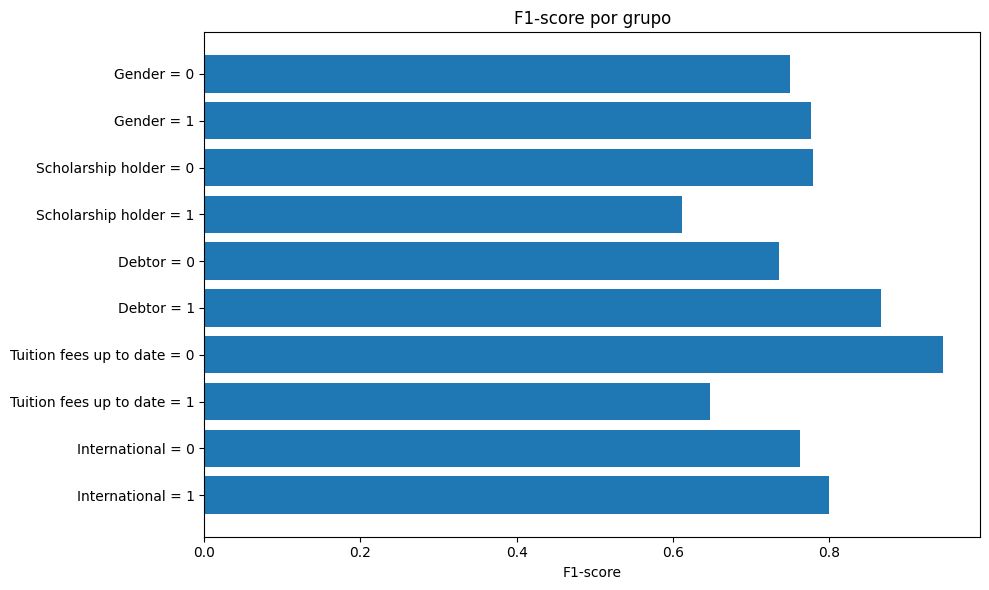

In [10]:
plt.figure(figsize=(10, 6))

plot_df = fairness_results.copy()
plot_df["label"] = plot_df["variable"].astype(str) + " = " + plot_df["group"].astype(str)

plt.barh(
    plot_df["label"][::-1],
    plot_df["f1"][::-1]
)

plt.xlabel("F1-score")
plt.title("F1-score por grupo")
plt.tight_layout()
plt.savefig("../results/figures/fairness_f1_by_group.png", dpi=300)
plt.show()

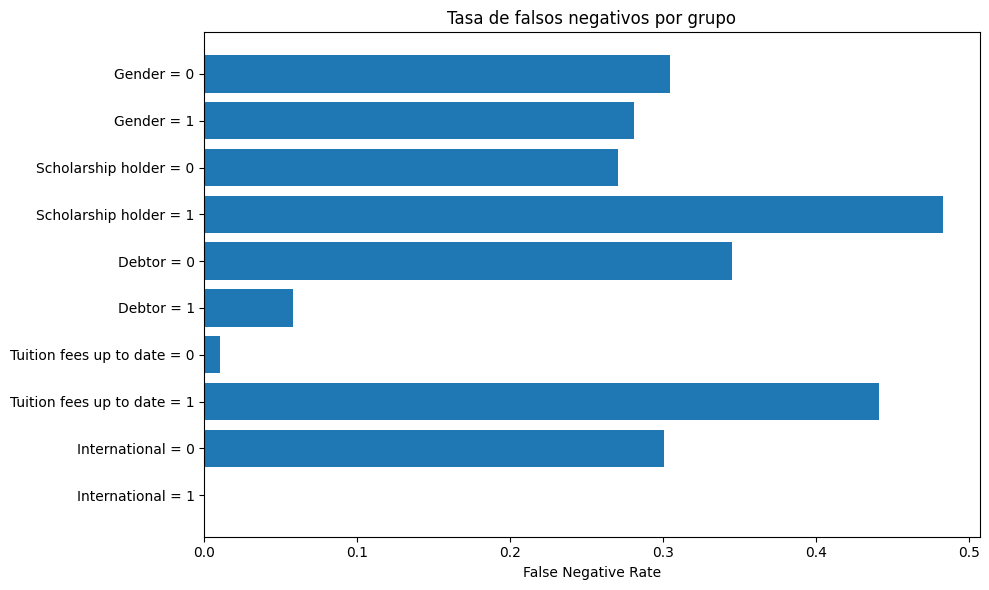

In [11]:
plt.figure(figsize=(10, 6))

plot_df = fairness_results.copy()
plot_df["label"] = plot_df["variable"].astype(str) + " = " + plot_df["group"].astype(str)

plt.barh(
    plot_df["label"][::-1],
    plot_df["false_negative_rate"][::-1]
)

plt.xlabel("False Negative Rate")
plt.title("Tasa de falsos negativos por grupo")
plt.tight_layout()
plt.savefig("../results/figures/fairness_false_negative_rate_by_group.png", dpi=300)
plt.show()

## Tabla para presentación

Se genera una versión reducida de la tabla de fairness con las columnas más útiles para el informe y la presentación.

In [12]:
fairness_summary_for_presentation = fairness_results[
    [
        "variable",
        "group",
        "n_students",
        "real_dropout_rate",
        "predicted_dropout_rate",
        "recall",
        "f1",
        "false_negative_rate"
    ]
].copy()

fairness_summary_for_presentation.to_csv(
    "../results/tables/fairness_summary_for_presentation.csv",
    index=False
)

fairness_summary_for_presentation

,variable,group,n_students,real_dropout_rate,predicted_dropout_rate,recall,f1,false_negative_rate
0,Gender,0,564,0.244681,0.209220,0.695652,0.750000,0.304348
1,Gender,1,321,0.454829,0.386293,0.719178,0.777778,0.280822
2,Scholarship holder,0,654,0.389908,0.339450,0.729412,0.779874,0.270588
3,Scholarship holder,1,231,0.125541,0.086580,0.517241,0.612245,0.482759
4,Debtor,0,795,0.291824,0.227673,0.655172,0.736077,0.344828
5,Debtor,1,90,0.577778,0.677778,0.942308,0.867257,0.057692
6,Tuition fees up to date,0,114,0.859649,0.938596,0.989796,0.946341,0.010204
7,Tuition fees up to date,1,771,0.241245,0.175097,0.559140,0.647975,0.440860
8,International,0,859,0.321304,0.267753,0.699275,0.762846,0.300725
9,International,1,26,0.307692,0.461538,1.000000,0.800000,0.000000


## Mitigación por umbrales combinados

Se cargan los resultados de la mitigación combinada por `Scholarship holder` y `Tuition fees up to date`. Después se agregan por separado para interpretar el efecto sobre beca y tasas al día.

,variable,group,n_students,precision,recall,f1,false_negative_rate,false_positive_rate,tp,fp,tn,fn,modelo
0,Scholarship holder,0,654,0.837838,0.729412,0.779874,0.270588,0.090226,186,36,363,69,Original
1,Scholarship holder,0,654,0.563510,0.956863,0.709302,0.043137,0.473684,244,189,210,11,Mitigado
2,Scholarship holder,1,231,0.750000,0.517241,0.612245,0.482759,0.024752,15,5,197,14,Original
3,Scholarship holder,1,231,0.370370,0.689655,0.481928,0.310345,0.168317,20,34,168,9,Mitigado


,variable,group,n_students,precision,recall,f1,false_negative_rate,false_positive_rate,tp,fp,tn,fn,modelo
0,Tuition fees up to date,0,114,0.906542,0.989796,0.946341,0.010204,0.625000,97,10,6,1,Original
1,Tuition fees up to date,0,114,0.907407,1.000000,0.951456,0.000000,0.625000,98,10,6,0,Mitigado
2,Tuition fees up to date,1,771,0.770370,0.559140,0.647975,0.440860,0.052991,104,31,554,82,Original
3,Tuition fees up to date,1,771,0.437995,0.892473,0.587611,0.107527,0.364103,166,213,372,20,Mitigado


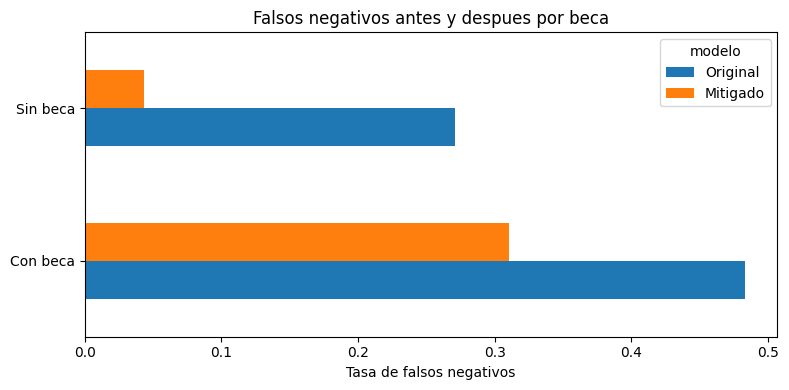

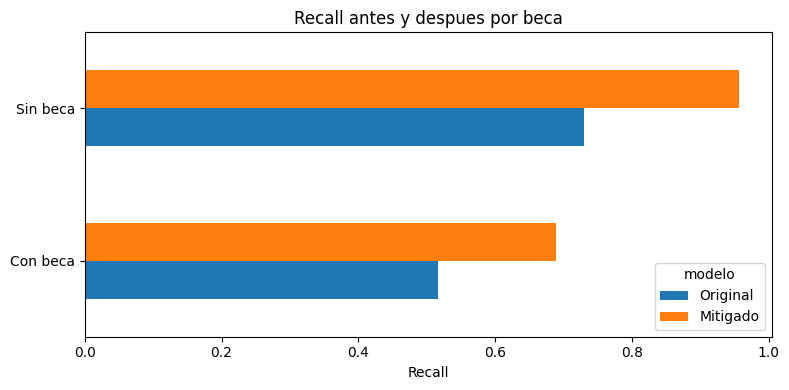

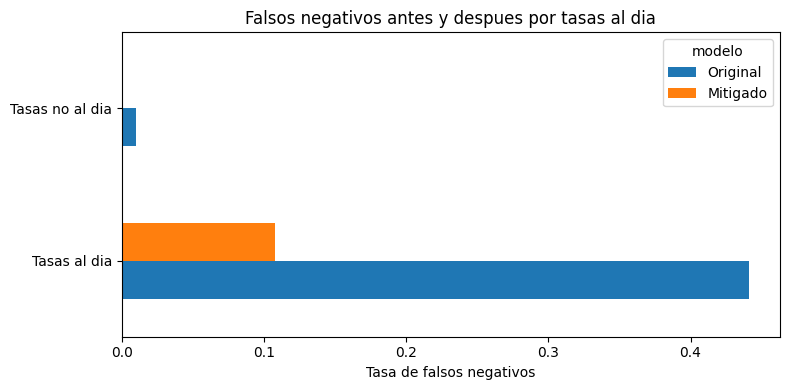

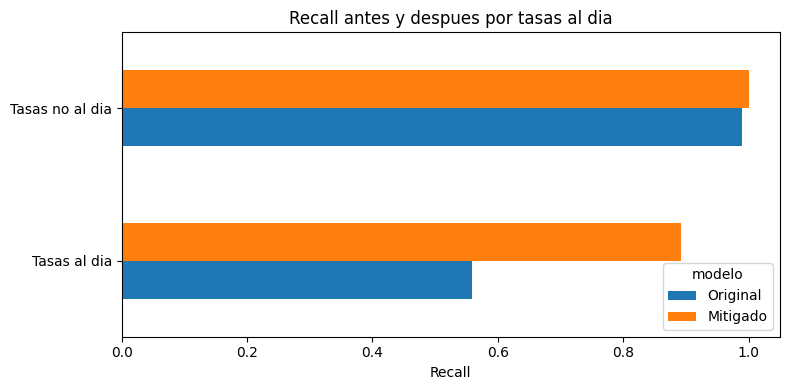

In [13]:
mitigation_comparison_path = "../results/tables/fairness_mitigation_scholarship_tuition_comparison.csv"
mitigation_comparison = pd.read_csv(mitigation_comparison_path)


def parse_intersection_group(group_label):
    values = {}
    for part in group_label.split(" | "):
        variable, value = part.split(" = ")
        values[variable] = int(value)
    return pd.Series(values)


parsed_groups = mitigation_comparison["group"].apply(parse_intersection_group)
mitigation_comparison = pd.concat([mitigation_comparison, parsed_groups], axis=1)


def aggregate_mitigation_metrics(metrics_df, variable):
    rows = []

    for (group_value, model_label), group_df in metrics_df.groupby([variable, "modelo"]):
        tp = group_df["tp"].sum()
        fp = group_df["fp"].sum()
        tn = group_df["tn"].sum()
        fn = group_df["fn"].sum()
        n_students = group_df["n_students"].sum()

        precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
        recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else np.nan

        rows.append({
            "variable": variable,
            "group": group_value,
            "n_students": n_students,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "false_negative_rate": fn / (fn + tp) if (fn + tp) > 0 else np.nan,
            "false_positive_rate": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
            "tp": tp,
            "fp": fp,
            "tn": tn,
            "fn": fn,
            "modelo": model_label
        })

    result = pd.DataFrame(rows)
    result["modelo"] = pd.Categorical(result["modelo"], ["Original", "Mitigado"], ordered=True)
    return result.sort_values(["group", "modelo"]).reset_index(drop=True)


sch_comparison = aggregate_mitigation_metrics(mitigation_comparison, "Scholarship holder")
tuition_comparison = aggregate_mitigation_metrics(mitigation_comparison, "Tuition fees up to date")

sch_comparison.to_csv(
    "../results/tables/fairness_mitigation_combined_by_scholarship.csv",
    index=False
)
tuition_comparison.to_csv(
    "../results/tables/fairness_mitigation_combined_by_tuition.csv",
    index=False
)

display(sch_comparison)
display(tuition_comparison)


def plot_metric_comparison(comparison_df, metric, labels, xlabel, title, output_path):
    plot_df = comparison_df.copy()
    plot_df["label"] = plot_df["group"].map(labels).fillna(plot_df["group"].astype(str))

    pivot_df = plot_df.pivot(index="label", columns="modelo", values=metric)
    pivot_df = pivot_df[[col for col in ["Original", "Mitigado"] if col in pivot_df.columns]]

    pivot_df.plot(kind="barh", figsize=(8, 4))
    plt.xlabel(xlabel)
    plt.ylabel("")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


scholarship_labels = {0: "Sin beca", 1: "Con beca"}
tuition_labels = {0: "Tasas no al dia", 1: "Tasas al dia"}

plot_metric_comparison(
    sch_comparison,
    "false_negative_rate",
    scholarship_labels,
    "Tasa de falsos negativos",
    "Falsos negativos antes y despues por beca",
    "../results/figures/fnr_beca_separado.png"
)

plot_metric_comparison(
    sch_comparison,
    "recall",
    scholarship_labels,
    "Recall",
    "Recall antes y despues por beca",
    "../results/figures/recall_beca_separado.png"
)

plot_metric_comparison(
    tuition_comparison,
    "false_negative_rate",
    tuition_labels,
    "Tasa de falsos negativos",
    "Falsos negativos antes y despues por tasas al dia",
    "../results/figures/fnr_tuition_separado.png"
)

plot_metric_comparison(
    tuition_comparison,
    "recall",
    tuition_labels,
    "Recall",
    "Recall antes y despues por tasas al dia",
    "../results/figures/recall_tuition_separado.png"
)

## Umbrales elegidos

Esta tabla traduce los umbrales usados en la mitigación combinada a etiquetas legibles para incluirlos en el informe.

In [14]:
thresholds_df = mitigation_comparison.loc[
    mitigation_comparison["modelo"] == "Mitigado",
    ["group", "threshold_used"]
].copy()

thresholds_df = thresholds_df.rename(columns={
    "group": "grupo",
    "threshold_used": "umbral_elegido"
})

thresholds_df["grupo"] = thresholds_df["grupo"].replace({
    "Scholarship holder = 0 | Tuition fees up to date = 0": "Sin beca + tasas no al dia",
    "Scholarship holder = 0 | Tuition fees up to date = 1": "Sin beca + tasas al dia",
    "Scholarship holder = 1 | Tuition fees up to date = 0": "Con beca + tasas no al dia",
    "Scholarship holder = 1 | Tuition fees up to date = 1": "Con beca + tasas al dia"
})

thresholds_df

,grupo,umbral_elegido
4,Sin beca + tasas no al dia,0.20
5,Sin beca + tasas al dia,0.11
6,Con beca + tasas no al dia,0.68
7,Con beca + tasas al dia,0.12
